In [1]:
%load_ext autoreload
%autoreload 2

# IMPORTS

In [2]:
# Project setup
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
import warnings

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from src.config import RANDOM_STATE
from src.evaluation import ResultsTable, evaluate_model, plot_roc_curve
from src.preprocessing import (
    create_pipeline,
    prepare_data,
    prepare_features,
    prepare_target,
)

# settings
warnings.filterwarnings("ignore", category=UserWarning)

#  Data loading and preparation

In [4]:
data_path = project_root / 'data' / 'Airline_review.csv'
raw_df = pd.read_csv(data_path)

# remove duplicate reviews
raw_df = raw_df.drop_duplicates(
    subset=raw_df.columns.drop('Unnamed: 0'),
    ignore_index=True
)

# split the raw data into training-validation and test sets (80/20)
train_val_df, test_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=raw_df['Recommended']
)

# split the training-validation data into training and validation sets (80/20)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df['Recommended']
)

In [5]:
# columns to remove before modeling
cols_to_drop = [
    'Unnamed: 0',
    'Review Date',
    'Verified',
    'Route',
    'Airline Name',
    'Overall_Rating',
    'Aircraft',
    'Date Flown'
]

# data preparation
train_df = prepare_data(train_df, cols_to_drop)
val_df = prepare_data(val_df, cols_to_drop)
test_df = prepare_data(test_df, cols_to_drop)

# target preparation
train_df = prepare_target(train_df)
val_df = prepare_target(val_df)
test_df = prepare_target(test_df)

# feature preparation
X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)
X_test, y_test = prepare_features(test_df)

# Description of selected training methods and quality assessment metrics

## Model selection

**Logistic Regression** was selected as the baseline model because it is a simple, efficient, and widely used linear classifier for text classification. When combined with TF-IDF features, it often provides strong baseline performance while remaining easy to interpret and fast to train.

To evaluate whether better performance can be achieved, two additional models will be explored in the next stage of the project:
 - **LinearSVC** was chosen as a strong linear alternative that is well suited for high-dimensional sparse text representations such as TF-IDF.
 - **LightGBM** was selected as a nonlinear gradient boosting model capable of capturing more complex relationships between features.

In addition, a transformer-based **BERT** model will be evaluated separately to compare its performance with the traditional machine learning approaches.

The performance and suitability of all models will be discussed in the following notebooks.


---

## Evaluation metrics

Because the dataset is moderately imbalanced (approximately 66% negative and 34% positive reviews), the **F1-score** was chosen as the primary evaluation metric. Unlike accuracy, it takes both precision and recall into account and provides a more informative measure of classification performance for both classes.

The **ROC-AUC** score is used as a complementary metric because it evaluates the model's ability to distinguish between the two classes across different classification thresholds. This provides additional insight into the overall ranking quality of the predicted scores.

The model performance will also be examined using the **classification report** and the **confusion matrix**. These outputs help identify the types of errors made by the model and provide a more complete understanding of its strengths and limitations.

# Logistic Regression (baseline model)

In [ ]:
logreg_model = create_pipeline(
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
)

logreg_model.fit(X_train, y_train)

## Logistic Regression results

In [7]:
logreg_metrics = evaluate_model(logreg_model, X_train, y_train, X_val, y_val)


=== LogisticRegression ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2440
           1       0.89      0.81      0.85      1248

    accuracy                           0.90      3688
   macro avg       0.90      0.88      0.89      3688
weighted avg       0.90      0.90      0.90      3688

Confusion matrix (validation):
[[2318  122]
 [ 231 1017]]
Train F1: 0.9069
Validation F1: 0.8521
Train AUROC: 0.9824
Validation AUROC: 0.9638


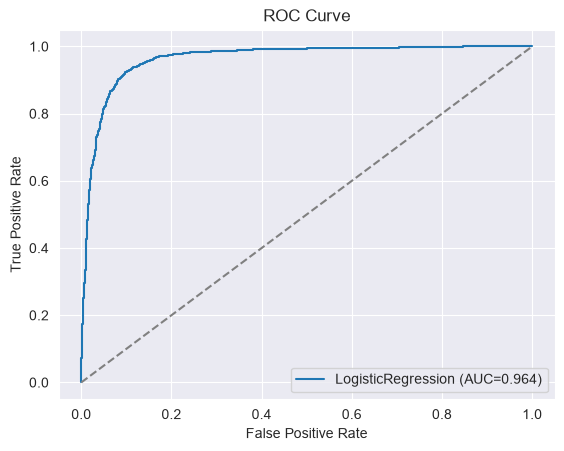

In [8]:
plot_roc_curve(logreg_model, X_val, y_val)

In [9]:
logreg_metrics['Configuration'] = 'max_iter=1000, TF-IDF: ngram_range=(1,2), min_df=2'

In [10]:
model_results = ResultsTable()
model_results.add_result(logreg_metrics)

In [11]:
# optionally
model_results.save()

In [12]:
model_results.display()

,Model,Configuration,Train_F1,Val_F1,Train_AUROC,Val_AUROC
0,LogisticRegression,"max_iter=1000, TF-IDF: ngram_range=(1,2), min_df=2",0.9069,0.8521,0.9824,0.9638


The baseline model achieved an `F1-score` of 0.852 and a `ROC-AUC` of 0.964 on the validation set.
The results show that even a simple Logistic Regression with TF-IDF can classify reviews quite well.
However, the model still misses some positive reviews, so the next experiments will focus on improving the classification performance.